# Assignment 4  


## Part A

Annual: $\mu = 8\%$, $\sigma = 4\%$; returns normal i.i.d. One period:

$$\mu_{\text{period}} = \frac{\mu_{\text{annual}}}{n}, \qquad \sigma_{\text{period}} = \frac{\sigma_{\text{annual}}}{\sqrt{n}}$$

where $n$ is the number of such periods per year. Daily uses $n = 252$ trading days.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad
mu_a, sigma_a = 0.08, 0.04

N_DAYS = 252


def daily_winning_updown_sharpe(mu_annual: float, sigma_annual: float):
    """Daily i.i.d. normal; winning rate, up-down ratio, annual Sharpe (μ/σ, rf=0)."""
    mu_p = mu_annual / N_DAYS
    sigma_p = sigma_annual / np.sqrt(N_DAYS)

    def f_R(r):
        return stats.norm.pdf(r, loc=mu_p, scale=sigma_p)

    num_pos, _ = quad(lambda r: r * f_R(r), 0.0, np.inf)
    den_pos, _ = quad(f_R, 0.0, np.inf)
    num_neg, _ = quad(lambda r: r * f_R(r), -np.inf, 0.0)
    den_neg, _ = quad(f_R, -np.inf, 0.0)
    E_pos = num_pos / den_pos
    E_neg = num_neg / den_neg
    winning_rate = den_pos
    up_down = E_pos / abs(E_neg)
    sharpe = mu_annual / sigma_annual if sigma_annual > 0 else np.nan
    return winning_rate, up_down, sharpe

### A i)

In [31]:
n = 1  # one year
mu_p = mu_a / n
sigma_p = sigma_a / np.sqrt(n)
p_loss = stats.norm.cdf(0.0, loc=mu_p, scale=sigma_p)

print("A(i)  P(loss in a given year)")
print(f"      μ_year = {mu_p:.4f}, σ_year = {sigma_p:.4f}")
print(f"      Answer: {p_loss:.6f}  ({100*p_loss:.4f}%)")

A(i)  P(loss in a given year)
      μ_year = 0.0800, σ_year = 0.0400
      Answer: 0.022750  (2.2750%)


### A ii)

In [32]:
n = 4  # quarters per year
mu_p = mu_a / n
sigma_p = sigma_a / np.sqrt(n)
p_loss = stats.norm.cdf(0.0, loc=mu_p, scale=sigma_p)

print("A(ii) P(loss in a given quarter)")
print(f"      μ_quarter = {mu_p:.4f}, σ_quarter = {sigma_p:.4f}")
print(f"      Answer: {p_loss:.6f}  ({100*p_loss:.4f}%)")

A(ii) P(loss in a given quarter)
      μ_quarter = 0.0200, σ_quarter = 0.0200
      Answer: 0.158655  (15.8655%)


### A iii)

In [33]:
n = 12  # months per year
mu_p = mu_a / n
sigma_p = sigma_a / np.sqrt(n)
p_loss = stats.norm.cdf(0.0, loc=mu_p, scale=sigma_p)

print("A(iii) P(loss in a given month)")
print(f"      μ_month = {mu_p:.6f}, σ_month = {sigma_p:.6f}")
print(f"      Answer: {p_loss:.6f}  ({100*p_loss:.4f}%)")

A(iii) P(loss in a given month)
      μ_month = 0.006667, σ_month = 0.011547
      Answer: 0.281851  (28.1851%)


### A iv)

In [34]:
n = 252  # trading days per year
mu_p = mu_a / n
sigma_p = sigma_a / np.sqrt(n)
p_loss = stats.norm.cdf(0.0, loc=mu_p, scale=sigma_p)

print("A(iv) P(loss on a given day)")
print(f"      μ_day = {mu_p:.8f}, σ_day = {sigma_p:.6f}")
print(f"      Answer: {p_loss:.6f}  ({100*p_loss:.4f}%)")

A(iv) P(loss on a given day)
      μ_day = 0.00031746, σ_day = 0.002520
      Answer: 0.449871  (44.9871%)


### A v)

In [35]:
notional = 500_000_000.0
n = 4
mu_q = mu_a / n
sigma_q = sigma_a / np.sqrt(n)

e_pnl = notional * mu_q
std_pnl = notional * sigma_q

print("A(v)  $500M invested, end of first quarter")
print(f"      Expected dollar PnL:     ${e_pnl:,.0f}")
print(f"      Std dev of dollar PnL: ${std_pnl:,.0f}")
print(f"      ±2σ band for dollar PnL: [${e_pnl - 2*std_pnl:,.0f}, ${e_pnl + 2*std_pnl:,.0f}]")

A(v)  $500M invested, end of first quarter
      Expected dollar PnL:     $10,000,000
      Std dev of dollar PnL: $10,000,000
      ±2σ band for dollar PnL: [$-10,000,000, $30,000,000]


## Part B — Winning rate, conditional means, up–down ratio, loss ratio

Uses $\mu_p$, $\sigma_p$ from **A(iv)** (daily $R \sim \mathcal{N}(\mu_p, \sigma_p^2)$). Run **A(iv)** before this cell.

**Winning rate** (fraction of up days):

$$P(R > 0) = \int_0^{\infty} f_R(r)\,dr$$

where $f_R$ is the normal PDF with $(\mu_p, \sigma_p)$ — computed as `1 - cdf(0)`.

**Conditional expectations** (definition, no standardization): the expected return **given** an up or down day is the integral of $r \cdot f_R(r)$ over that region, divided by the probability of that region:

$$\mathbb{E}[R \mid R > 0] = \frac{\displaystyle\int_0^{\infty} r\, f_R(r)\,dr}{\displaystyle\int_0^{\infty} f_R(r)\,dr}, \qquad
\mathbb{E}[R \mid R < 0] = \frac{\displaystyle\int_{-\infty}^{0} r\, f_R(r)\,dr}{\displaystyle\int_{-\infty}^{0} f_R(r)\,dr}$$

We evaluate the integrals numerically with `scipy.integrate.quad` and the same $\mathcal{N}(\mu_p, \sigma_p^2)$ density throughout.

- **Up–down ratio** (assignment): $\dfrac{\mathbb{E}[R \mid R > 0]}{\big|\mathbb{E}[R \mid R < 0]\big|}$.
- **Loss ratio** (conditional): $\dfrac{\big|\mathbb{E}[R \mid R < 0]\big|}{\mathbb{E}[R \mid R > 0]}$ (reciprocal of up–down).

In [36]:
# Uses mu_p, sigma_p from A(iv); EV via definition: ∫ r f(r) dr / P(region)
def f_R(r):
    return stats.norm.pdf(r, loc=mu_p, scale=sigma_p)

num_pos, _ = quad(lambda r: r * f_R(r), 0.0, np.inf)
den_pos, _ = quad(f_R, 0.0, np.inf)
E_R_given_pos = num_pos / den_pos

num_neg, _ = quad(lambda r: r * f_R(r), -np.inf, 0.0)
den_neg, _ = quad(f_R, -np.inf, 0.0)
E_R_given_neg = num_neg / den_neg

winning_rate = den_pos  # P(R > 0)
loss_rate = den_neg   # P(R < 0)

up_down_ratio = E_R_given_pos / abs(E_R_given_neg)
loss_ratio_conditional = abs(E_R_given_neg) / E_R_given_pos

print("A(iv) daily: μ_p = {:.8f}, σ_p = {:.6f}".format(mu_p, sigma_p))
print()
print("Winning rate P(R > 0)     = {:.6f}  ({:.2f}%)".format(winning_rate, 100 * winning_rate))
print("Loss rate   P(R < 0)     = {:.6f}  ({:.2f}%)".format(loss_rate, 100 * loss_rate))
print()
print("E[R | R > 0]             = {:.8f}".format(E_R_given_pos))
print("E[R | R < 0]             = {:.8f}".format(E_R_given_neg))
print()
print("Up-down ratio (E[up]/|E[down]|) = {:.6f}".format(up_down_ratio))
print("Loss ratio |E[down]|/E[up]      = {:.6f}".format(loss_ratio_conditional))

A(iv) daily: μ_p = 0.00031746, σ_p = 0.002520

Winning rate P(R > 0)     = 0.550129  (55.01%)
Loss rate   P(R < 0)     = 0.449871  (44.99%)

E[R | R > 0]             = 0.00213029
E[R | R < 0]             = -0.00189938

Up-down ratio (E[up]/|E[down]|) = 1.121571
Loss ratio |E[down]|/E[up]      = 0.891606


### B (i) — Vary $\sigma_{\text{annual}}$, hold $\mu = 8\%$

$\sigma$ steps by **0.25%** from **2%** to **12%** (annualized). Daily dynamics use the same scaling as Part A ($n=252$). **Sharpe** (annual, $r_f=0$): $\mu_{\text{annual}}/\sigma_{\text{annual}}$.

Table: three columns — **Winning rate**, **Up–down ratio**, **Sharpe**; one row per $\sigma$.

σ annual (%),Winning rate,Up-down ratio,Sharpe
2.00,0.5995,1.2577,4.0000
2.25,0.5886,1.2261,3.5556
2.50,0.5799,1.2014,3.2000
2.75,0.5727,1.1816,2.9091
3.00,0.5667,1.1653,2.6667
3.25,0.5616,1.1516,2.4615
3.50,0.5572,1.1401,2.2857
3.75,0.5535,1.1302,2.1333
4.00,0.5501,1.1216,2.0000
4.25,0.5472,1.1140,1.8824


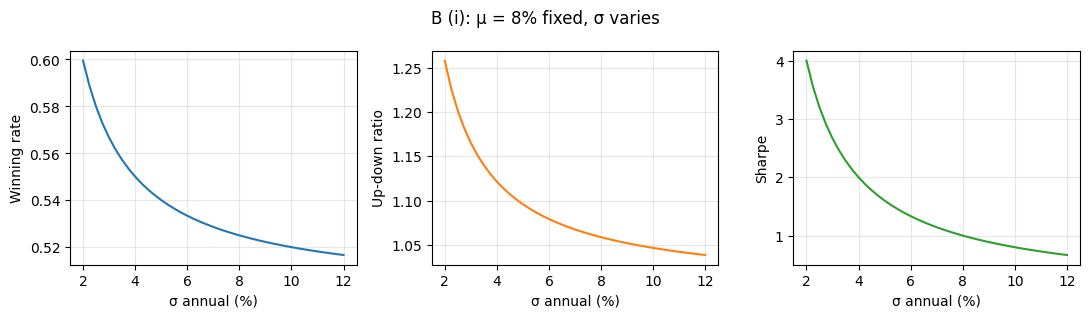

In [37]:
sigma_grid_pct = np.arange(2.0, 12.25, 0.25)
mu_fixed = 0.08
rows_bi = []
for spct in sigma_grid_pct:
    s = spct / 100.0
    wr, ud, sh = daily_winning_updown_sharpe(mu_fixed, s)
    rows_bi.append(
        {"σ annual (%)": spct, "Winning rate": wr, "Up-down ratio": ud, "Sharpe": sh}
    )
df_bi = pd.DataFrame(rows_bi)
display(
    df_bi.style.format(
        {"σ annual (%)": "{:.2f}", "Winning rate": "{:.4f}", "Up-down ratio": "{:.4f}", "Sharpe": "{:.4f}"}
    ).hide(axis="index")
)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharex=True)
x = df_bi["σ annual (%)"]
axes[0].plot(x, df_bi["Winning rate"], color="C0")
axes[0].set_ylabel("Winning rate")
axes[1].plot(x, df_bi["Up-down ratio"], color="C1")
axes[1].set_ylabel("Up-down ratio")
axes[2].plot(x, df_bi["Sharpe"], color="C2")
axes[2].set_ylabel("Sharpe")
for ax in axes:
    ax.set_xlabel("σ annual (%)")
    ax.grid(True, alpha=0.3)
fig.suptitle("B (i): μ = 8% fixed, σ varies")
fig.tight_layout()
plt.show()

### B (ii) — Vary $\mu_{\text{annual}}$, hold $\sigma = 4\%$

$\mu$ steps by **0.25%** from **2%** to **12%**. Same daily metrics and Sharpe definition as above.

μ annual (%),Winning rate,Up-down ratio,Sharpe
2.00,0.5126,1.0291,0.5000
2.25,0.5141,1.0328,0.5625
2.50,0.5157,1.0365,0.6250
2.75,0.5173,1.0402,0.6875
3.00,0.5188,1.0440,0.7500
3.25,0.5204,1.0477,0.8125
3.50,0.5220,1.0515,0.8750
3.75,0.5235,1.0553,0.9375
4.00,0.5251,1.0591,1.0000
4.25,0.5267,1.0629,1.0625


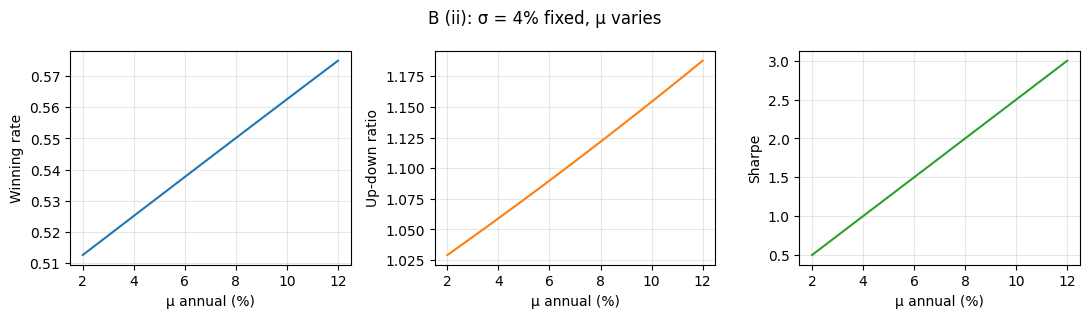

In [38]:
mu_grid_pct = np.arange(2.0, 12.25, 0.25)
sigma_fixed = 0.04
rows_bii = []
for mpct in mu_grid_pct:
    m = mpct / 100.0
    wr, ud, sh = daily_winning_updown_sharpe(m, sigma_fixed)
    rows_bii.append(
        {"μ annual (%)": mpct, "Winning rate": wr, "Up-down ratio": ud, "Sharpe": sh}
    )
df_bii = pd.DataFrame(rows_bii)
display(
    df_bii.style.format(
        {"μ annual (%)": "{:.2f}", "Winning rate": "{:.4f}", "Up-down ratio": "{:.4f}", "Sharpe": "{:.4f}"}
    ).hide(axis="index")
)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharex=True)
x = df_bii["μ annual (%)"]
axes[0].plot(x, df_bii["Winning rate"], color="C0")
axes[0].set_ylabel("Winning rate")
axes[1].plot(x, df_bii["Up-down ratio"], color="C1")
axes[1].set_ylabel("Up-down ratio")
axes[2].plot(x, df_bii["Sharpe"], color="C2")
axes[2].set_ylabel("Sharpe")
for ax in axes:
    ax.set_xlabel("μ annual (%)")
    ax.grid(True, alpha=0.3)
fig.suptitle("B (ii): σ = 4% fixed, μ varies")
fig.tight_layout()
plt.show()

B iii) 

We can almost think of the sharpe ratio being intimiately related to winning rate and the up/down ratio. The winning rate tells you how often you win, the up/down ratio tells you whether when you win/lose how large are those relative wins or losses. For a good sharpe ratio you need good winning ratio and up/down ratio. 


Let's think of the most important assumption of this problem IID: if returns are not IID that means they are somewhat autocorrelated. As a result of this You could have period s

I am confused here.